# Part II: Exploratory Data Analysis(EDA)

## Basic settings

In [49]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
import os
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
pd.options.display.max_rows = 50
pd.options.display.max_columns = None

In [51]:
DATA_DIR = "../data/processed"

## Load processed data

In [52]:
df_inventory = pd.read_csv(os.path.join(DATA_DIR, "inventory_processed.csv"), parse_dates = ["date"])

In [53]:
df_inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109650 entries, 0 to 109649
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   sku_id           109650 non-null  object        
 1   date             109650 non-null  datetime64[ns]
 2   demand           109650 non-null  int64         
 3   sales_quantity   109650 non-null  int64         
 4   inventory_level  109650 non-null  int64         
 5   order_received   109650 non-null  int64         
 6   category         109650 non-null  object        
 7   lead_time        109650 non-null  int64         
 8   safety_stock     109650 non-null  int64         
 9   reorder_point    109650 non-null  int64         
 10  order_quantity   109650 non-null  int64         
 11  unit_cost        109650 non-null  float64       
 12  unit_price       109650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(8), object(2)
memory usage: 10.9+ 

In [54]:
print("Statistical summary")
print(df_inventory.describe())

print("\nDate range: {} to {}".format(df_inventory['date'].min(), df_inventory['date'].max()))

print("\nNumber of unique products: {}".format(df_inventory['sku_id'].nunique()))

Statistical summary
                      date         demand  sales_quantity  inventory_level  \
count               109650  109650.000000   109650.000000    109650.000000   
mean   2024-12-31 00:00:00      15.028299       14.385846       337.580164   
min    2024-01-01 00:00:00       0.000000        0.000000         0.000000   
25%    2024-07-01 00:00:00       8.000000        7.000000       186.000000   
50%    2024-12-31 00:00:00      13.000000       12.000000       318.000000   
75%    2025-07-02 00:00:00      20.000000       20.000000       475.000000   
max    2025-12-31 00:00:00      75.000000       75.000000       937.000000   
std                    NaN       9.711968        9.650186       196.420558   

       order_received      lead_time   safety_stock  reorder_point  \
count   109650.000000  109650.000000  109650.000000  109650.000000   
mean        14.421332       6.646667      44.260000     145.546667   
min          0.000000       3.000000      10.000000      65.000000 

## Perfome EDA

### Demand overview

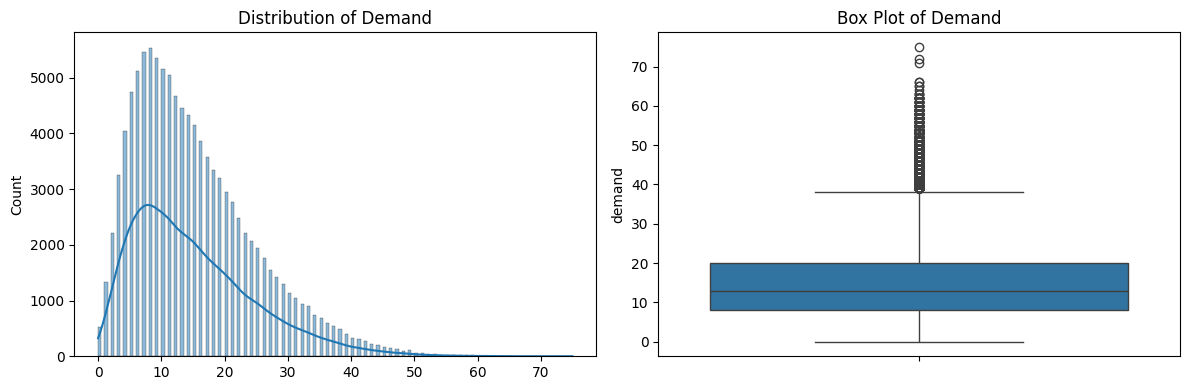

In [55]:
fig, ax = plt.subplots(1, 2, figsize = (12, 4))
sns.histplot(df_inventory['demand'], ax = ax[0], kde = True)
ax[0].set_title("Distribution of Demand")
ax[0].set_xlabel("")
sns.boxplot(y = df_inventory['demand'], ax = ax[1])
ax[1].set_title("Box Plot of Demand")
plt.tight_layout()
plt.show()

- Demand is right-skewed, with most values concentrated around 8–15 units.
- There is a long tail of high-demand spikes (up to 70+ units).
- The boxplot shows many upper outliers.
- These outliers indicate occasional but significant demand surges.

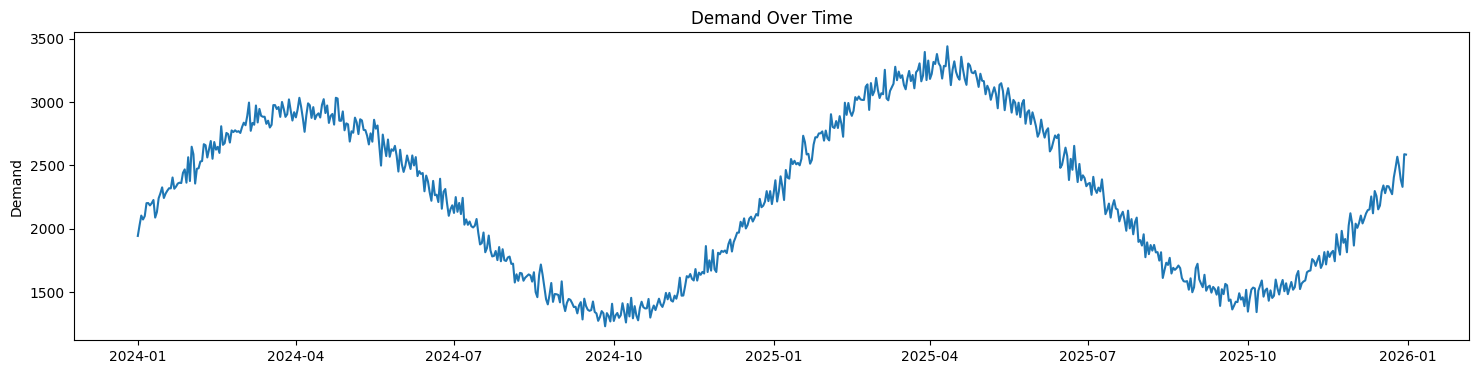

In [56]:
daily_sales_df = df_inventory.groupby('date')['demand'].sum().reset_index()
plt.figure(figsize = (18, 4))
plt.plot(daily_sales_df['date'], daily_sales_df['demand'])
plt.title("Demand Over Time")
plt.ylabel("Demand")
plt.show()

- Demand shows a clear seasonal pattern.
- Peaks and troughs repeat annually.
- The second year has higher peaks than the first.
- This indicates a slight upward trend.
- Both trend and seasonality are important drivers.

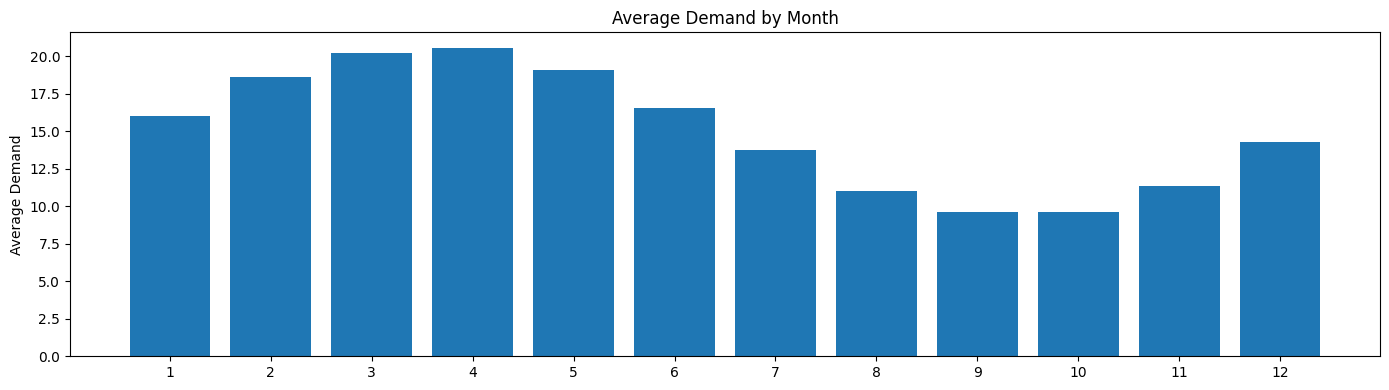

In [57]:
plt.figure(figsize = (14, 4))
df = df_inventory.copy()
df["month"] = df["date"].dt.month
df_demand_by_month = df.groupby("month")["demand"].mean().reset_index()

plt.bar(df_demand_by_month['month'], df_demand_by_month['demand'])
plt.title("Average Demand by Month")
plt.ylabel("Average Demand")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

- Demand increases from January to April.
- Peak demand occurs around March–April.
- Demand declines from May to September.
- The lowest demand occurs around September–October.
- Demand starts to recover toward year-end.
- There is a clear within-year seasonal cycle.

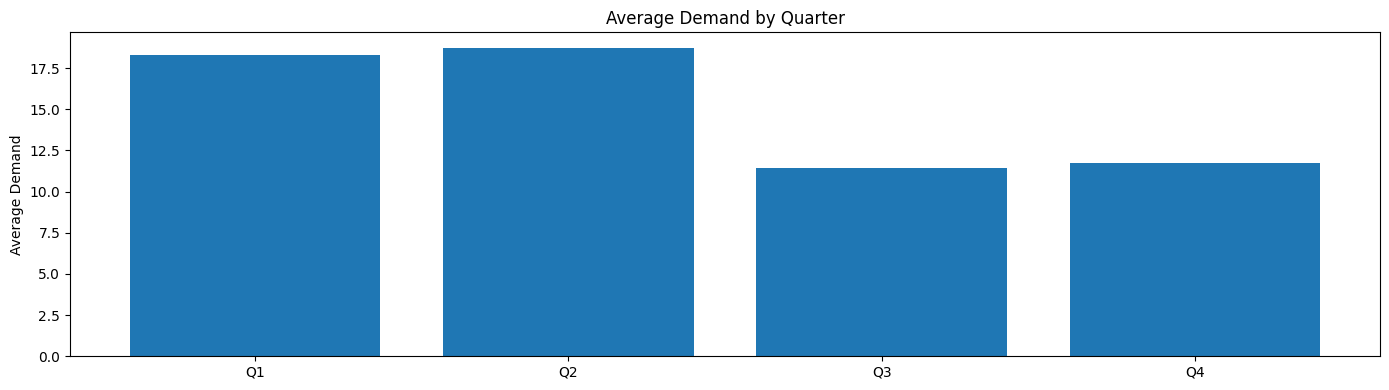

In [58]:
plt.figure(figsize = (14, 4))
df["quarter"] = df["date"].dt.quarter
df_demand_by_quarter = df.groupby("quarter")["demand"].mean().reset_index()

plt.bar(df_demand_by_quarter['quarter'], df_demand_by_quarter['demand'])
plt.title("Average Demand by Quarter")
plt.xticks(df_demand_by_quarter['quarter'], ["Q1", "Q2", "Q3", "Q4"])
plt.ylabel("Average Demand")
plt.tight_layout()
plt.show()

- Q2 has the highest demand.
- Q1 is the second strongest period.
- Q3 has the lowest demand.
- Q4 shows moderate recovery.
- There is a clear mid-year slowdown.

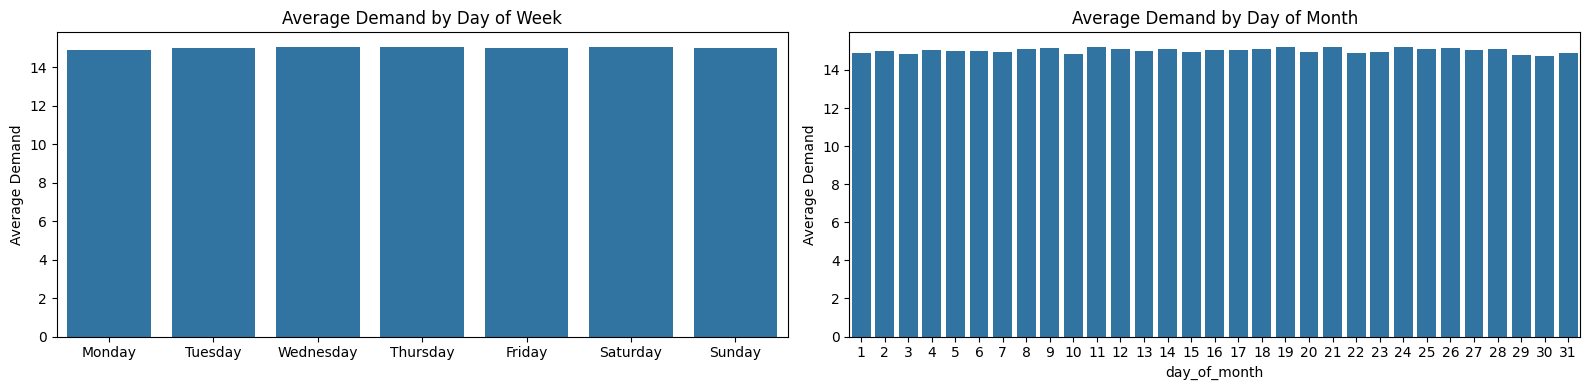

In [59]:
fig, ax = plt.subplots(1, 2,figsize = (16, 4))
df["day_of_week"] = df["date"].dt.dayofweek
day_names = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
df_demand_by_dayofweek = df.groupby("day_of_week")["demand"].mean().reindex(range(7))
sns.barplot(x = day_names, y = df_demand_by_dayofweek, ax = ax[0])
ax[0].set_title("Average Demand by Day of Week")
ax[0].set_ylabel("Average Demand")

df["day_of_month"] = df["date"].dt.day
df_demand_by_dayofmonth = df.groupby("day_of_month")["demand"].mean()

sns.barplot(x = df_demand_by_dayofmonth.index, y = df_demand_by_dayofmonth.values, ax = ax[1])
ax[1].set_title("Average Demand by Day of Month")
ax[1].set_ylabel("Average Demand")
plt.tight_layout()

- Demand is consistent across days of the week and days of the month.
- There are no noticeable spikes or patterns in daily demand.
- Weekly and intra-month seasonality are negligible.
- Daily timing is not a key driver of demand variation.

### Inventory operation

In [60]:
sku_metric = df_inventory.groupby("sku_id").agg(
    avg_inventory = ("inventory_level", "mean"),
    total_demand = ("demand", "sum"),
    total_sales = ("sales_quantity", "sum"),
    num_days = ("date", "nunique")
).reset_index()

sku_metric["daily_demand"] = sku_metric["total_demand"] / sku_metric["num_days"]
sku_metric["DOI"] = (sku_metric["avg_inventory"] / sku_metric["daily_demand"]).replace([np.inf, -np.inf], np.nan)
sku_metric["fill_rate"] = (sku_metric["total_sales"] / sku_metric["total_demand"]).replace([np.inf, -np.inf], np.nan)
sku_metric['lost_sales'] = (sku_metric['total_demand'] - sku_metric['total_sales']).replace([np.inf, -np.inf], np.nan)

In [61]:
cv_df = df_inventory.groupby("sku_id")["demand"].agg(["mean", "std"]).reset_index()
cv_df["CV"] = (cv_df["std"] / cv_df["mean"]).replace([np.inf, -np.inf], np.nan)

sku_metric = sku_metric.merge(cv_df[["sku_id", "CV"]], on="sku_id")

In [62]:
cols = ['lost_sales', 'fill_rate', 'DOI', 'CV']
sku_metric[cols].describe()

,lost_sales,fill_rate,DOI,CV
count,150.000000,150.000000,150.000000,150.000000
mean,469.633333,0.970106,29.515793,0.454726
std,1111.968998,0.063634,19.124123,0.048992
min,0.000000,0.639781,5.257462,0.384897
25%,0.000000,0.976331,15.294121,0.416865
50%,0.000000,1.000000,23.934806,0.439150
75%,269.250000,1.000000,40.294677,0.486373
max,7168.000000,1.000000,89.928763,0.575805


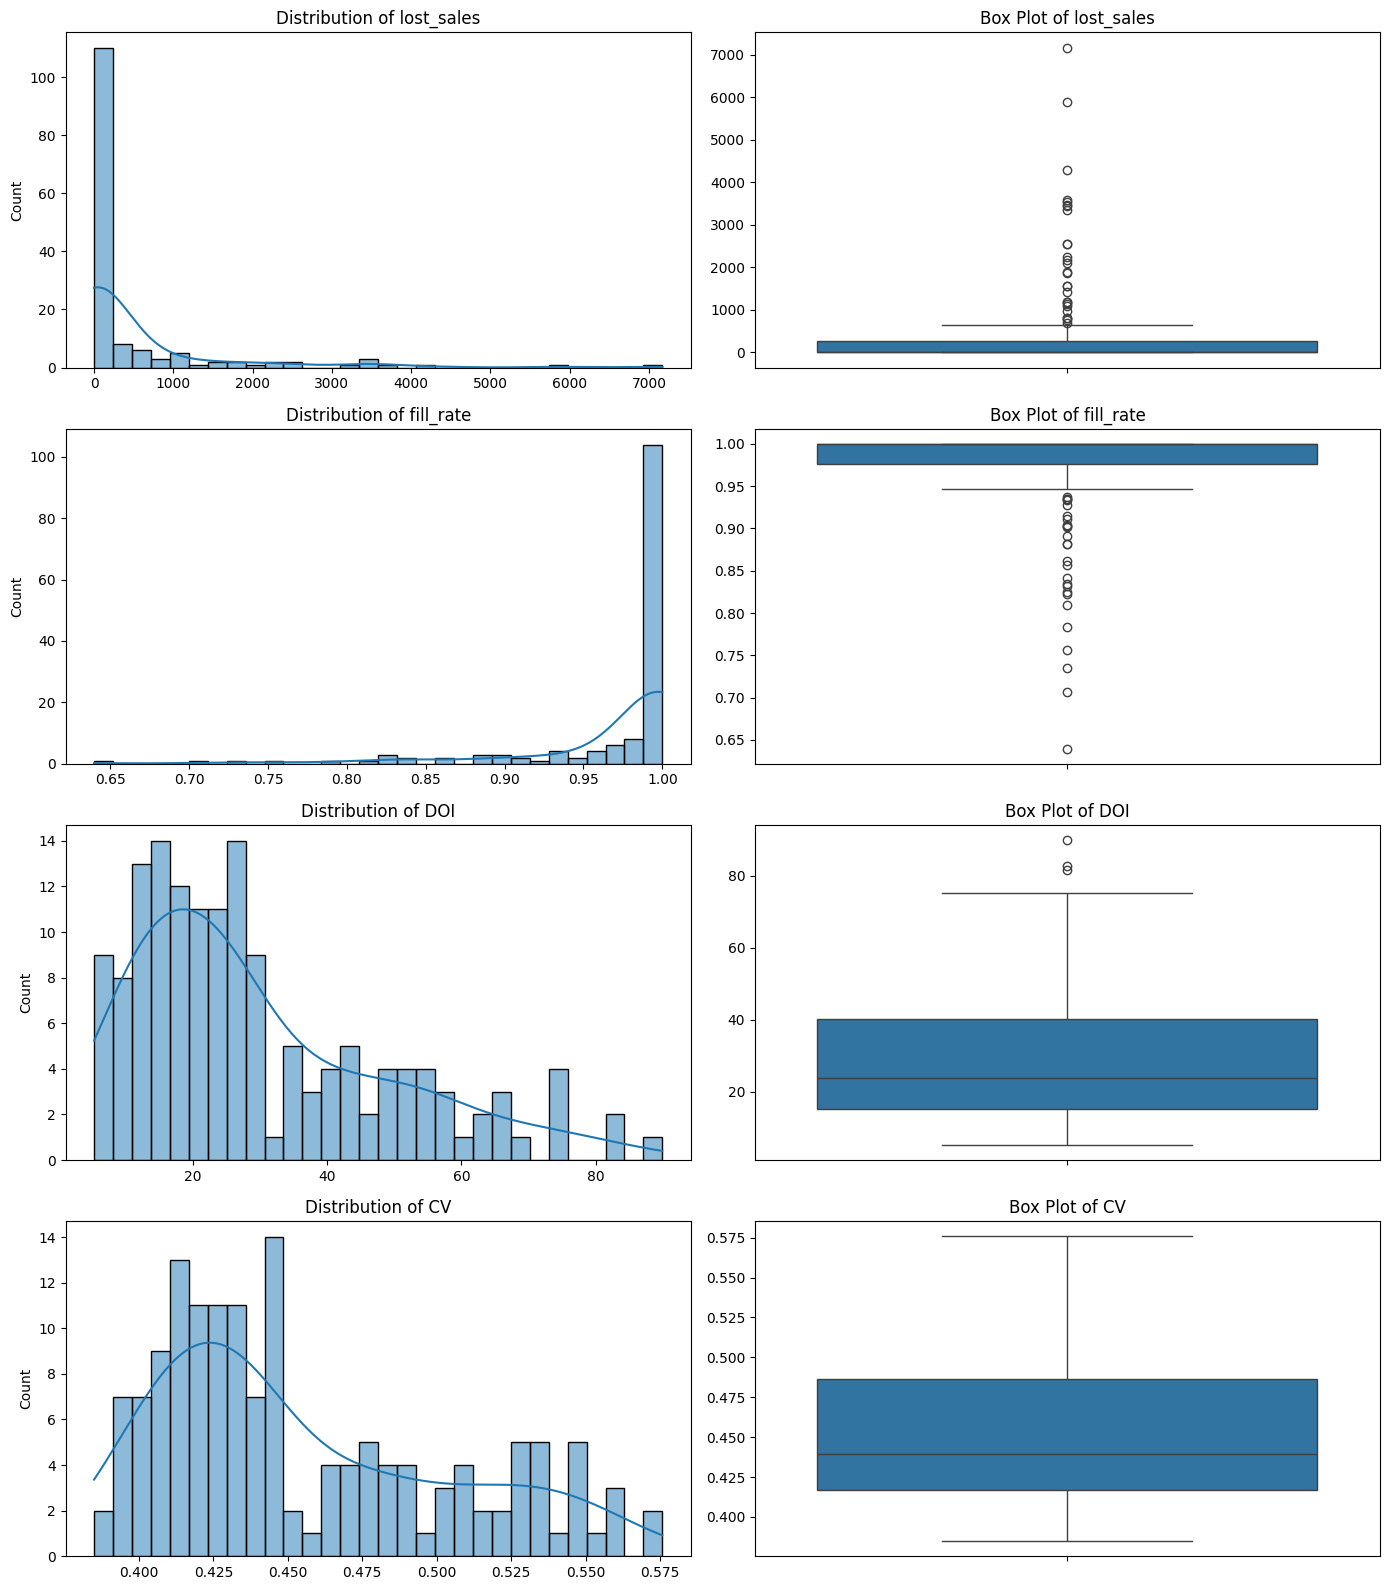

In [67]:
fig, axes = plt.subplots(len(cols), 2, figsize = (14, 4 * len(cols)))
for i, col in enumerate(cols):
    sns.histplot(sku_metric[col], bins = 30, kde = True, ax = axes[i, 0])
    axes[i, 0].set_title(f"Distribution of {col}")
    axes[i, 0].set_xlabel("")

    sns.boxplot(y = sku_metric[col], ax = axes[i, 1])
    axes[i, 1].set_title(f"Box Plot of {col}")
    axes[i, 1].set_ylabel("")
plt.tight_layout()
plt.show()

**Distribution Insights**
- Lost Sales: Highly right-skewed. Most SKUs have low lost sales, but a few contribute disproportionately high losses → issues are concentrated in a small subset of SKUs.
- Fill Rate: Strongly concentrated near 1.0. Overall service level is high, but a few SKUs underperform → uneven performance across SKUs.
- DOI: Right-skewed with some high outliers. Most SKUs hold reasonable inventory, but some show signs of potential overstock.
- CV: Moderately distributed around mid-range values, indicating varying demand variability across SKUs.

<Axes: >

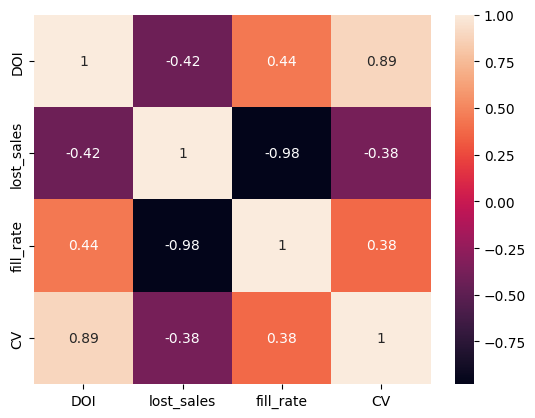

In [64]:
sns.heatmap(sku_metric[["DOI","lost_sales","fill_rate","CV"]].corr(), annot = True)

**Correlation Insights**
- Fill Rate vs Lost Sales (-0.98): Strong inverse relationship → both capture the same availability aspect.
- DOI vs Fill Rate (+0.44): Higher inventory generally improves service level.
- DOI vs Lost Sales (-0.42): More inventory reduces lost sales, but not perfectly → other factors matter.
- CV vs DOI (+0.89): Strong relationship → higher demand variability leads to higher inventory levels (reactive strategy).
- CV vs Fill Rate (+0.38): Variable SKUs still maintain decent service, likely due to higher inventory.

**Summary**

Inventory performance is generally strong but uneven across SKUs. A small number of items drive most lost sales. Inventory levels increase significantly with demand variability, suggesting a reactive approach that may maintain service levels but risks overstock.

## Save sku metric data

In [65]:
sku_metric.to_csv(os.path.join(DATA_DIR, "sku_metric.csv"), index=False)